![SWDB](../workshops/img/swdb_logo.jpg)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Workshop: Can We Trust This Connectivity Analysis?

A collaborator (or an LLM) gave us this notebook to answer the following scientific question:

**What is the probability that one excitatory neuron connects to another as a function of soma–soma Euclidean distance?**

The notebook runs without errors and produces a reasonable-looking figure.

**Can we trust the result?**

Rather than assuming the code is correct—or incorrect—we'll build evidence by reading the code, visualizing intermediate results, testing simple cases, and comparing against known expectations.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Analysis code we received

**Run the notebook below to generate the final result.**

At first glance, does the figure look plausible?

</div>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

In [2]:
def read_feather(path, columns=None):
    """Read a Feather/Arrow IPC file."""
    with open(path, "rb") as fh:
        table = ipc.open_file(fh).read_all()
    if columns is not None:
        table = table.select(columns)
    return table.to_pandas()


def get_soma_positions(cell_df, position_columns):
    """Return soma coordinates (in microns) for each root ID."""
    positions = (
        cell_df
        .set_index("pt_root_id")[position_columns]
        .to_numpy(dtype=float)
    ) / 1000.0
    return positions, position_columns


def distance_from_one_soma(pre_position, post_positions):
    """Distance from one soma to every candidate postsynaptic soma."""
    return np.abs(post_positions[:, 1] - pre_position[1])


def unique_connected_pairs(synapses, pre_ids, post_ids):
    """Find unique connected non-self pre/post pairs in the eligible pools."""
    in_pools = (
        synapses["pre_pt_root_id"].isin(pre_ids)
        & synapses["post_pt_root_id"].isin(post_ids)
        & (synapses["pre_pt_root_id"] != synapses["post_pt_root_id"])
    )
    return (
        synapses.loc[in_pools, ["pre_pt_root_id", "post_pt_root_id"]]
        .drop_duplicates()
    )


def count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=25.0,
    max_distance_um=900.0,
):
    """Count eligible and connected ordered pairs in distance bins."""
    edges = np.arange(0, max_distance_um + bin_width_um, bin_width_um)
    n_bins = len(edges) - 1
    total_counts = np.zeros(n_bins, dtype=int)
    connected_counts = np.zeros(n_bins, dtype=int)

    post_id_to_row = {root_id: i for i, root_id in enumerate(post_ids)}
    connected_by_pre = {
        pre_id: np.array(
            [post_id_to_row[p] for p in group["post_pt_root_id"] if p in post_id_to_row],
            dtype=int,
        )
        for pre_id, group in connected_pairs.groupby("pre_pt_root_id")
    }

    for i, pre_id in enumerate(pre_ids):
        distances = distance_from_one_soma(pre_positions[i], post_positions)

        self_row = post_id_to_row.get(pre_id)
        if self_row is not None:
            distances[self_row] = np.nan

        valid = np.isfinite(distances) & (distances < max_distance_um)
        bins = np.floor(distances[valid] / bin_width_um).astype(int)
        total_counts += np.bincount(bins, minlength=n_bins)[:n_bins]

        connected_rows = connected_by_pre.get(pre_id, np.array([], dtype=int))
        connected_distances = distances[connected_rows]
        valid_connected = (
            np.isfinite(connected_distances)
            & (connected_distances < max_distance_um)
        )
        connected_bins = np.floor(
            connected_distances[valid_connected] / bin_width_um
        ).astype(int)
        connected_counts += np.bincount(connected_bins, minlength=n_bins)[:n_bins]

    return edges, total_counts, connected_counts


def connection_probability(connected_counts, total_counts):
    """Calculate the connection probability in each distance bin."""
    connected_counts = np.asarray(connected_counts)
    total_counts = np.asarray(total_counts)
    denominator = total_counts.sum()
    probability = connected_counts / denominator
    return probability

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### 1. Load the data

</div>

In [3]:
DATA_DIR = Path("/root/capsule/data/v1dd_1196")
MAT = 1196
BIN_WIDTH_UM = 25.0
MAX_DISTANCE_UM = 900.0
MIN_PAIRS_PER_BIN = 200

cell = read_feather(DATA_DIR / f"soma_and_cell_type_{MAT}.feather")
proofread_axon_ids = np.load(DATA_DIR / f"proofread_axon_list_{MAT}.npy")
proofread_dendrite_ids = np.load(DATA_DIR / f"proofread_dendrite_list_{MAT}.npy")

synapses = read_feather(
    DATA_DIR / f"syn_df_all_to_proofread_to_all_{MAT}.feather",
    columns=["pre_pt_root_id", "post_pt_root_id"],
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### 2. Define the pre- and post-synaptic populations

</div>

In [4]:
soma_coord_columns = ["pt_position_trform_x", 
                      "pt_position_trform_y", 
                      "pt_position_trform_z"]

excitatory_cells = cell.loc[
    (cell["cell_type_coarse"] == "E")
    & (cell["pt_root_id"] != 0)
].copy()

excitatory_cells = (
    excitatory_cells
    .dropna(subset=soma_coord_columns)
    .drop_duplicates("pt_root_id")
)

pre_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_axon_ids)
].copy()

post_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_dendrite_ids)
].copy()

pre_ids = pre_cells["pt_root_id"].to_numpy()
post_ids = post_cells["pt_root_id"].to_numpy()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### 3. Count connected pairs as a function of distance

</div>

In [5]:
all_positions, position_columns = get_soma_positions(excitatory_cells, soma_coord_columns)
root_to_row = {
    root_id: i
    for i, root_id in enumerate(excitatory_cells["pt_root_id"].to_numpy())
}
pre_positions = all_positions[[root_to_row[root_id] for root_id in pre_ids]]
post_positions = all_positions[[root_to_row[root_id] for root_id in post_ids]]

connected_pairs = unique_connected_pairs(synapses, pre_ids, post_ids)


edges, total_counts, connected_counts = count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=BIN_WIDTH_UM,
    max_distance_um=MAX_DISTANCE_UM,
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### 4. Calculate and plot connection probability

</div>

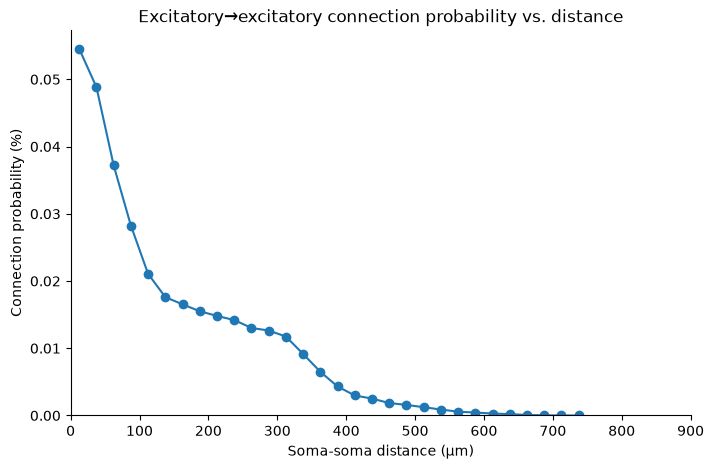

In [6]:
probability = connection_probability(
    connected_counts,
    total_counts,
)

centers = (edges[:-1] + edges[1:]) / 2

reliable = total_counts >= MIN_PAIRS_PER_BIN
show = reliable & np.isfinite(probability)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    centers[show],
    probability[show] * 100,
    marker="o",
)
ax.set(
    xlabel="Soma-soma distance (µm)",
    ylabel="Connection probability (%)",
    title="Excitatory→excitatory connection probability vs. distance",
    xlim=(0, MAX_DISTANCE_UM),
    ylim=(0, None),
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Can we trust this result?

The figure might look reasonable—but appearances aren't enough.

Let's start building evidence by checking one assumption at a time. We'll begin with one of the key quantities in the analysis: the distance between neuron somata.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### **Check 1: How is soma distance calculated?**

The analysis should compute the **Euclidean distance** between soma positions.

One of the best ways to build intuition is through *visualizing the data*. Before trusting the numbers, let's build intuition in two steps: first look at **where the somata are located in space**, then look at **the distances the code produces**.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 1: **Plot the soma positions** 

Where are the presynaptic (proofread-axon) neuron somata relative to the postsynaptic (proofread-dendrite) neuron somata?

Create a scatter plot showing the presynaptic soma position (`pre_positions`) overlaid on the postsynaptic soma positions (`post_positions`). 


*Hint*: `pre_positions` and `post_positions` contain soma coordinates in [x,y,z] order. y is the cortical depth axis (smaller values are more superficial). If you can't see both pre- and postsynaptic cells, try swapping the plotting order.

</div>

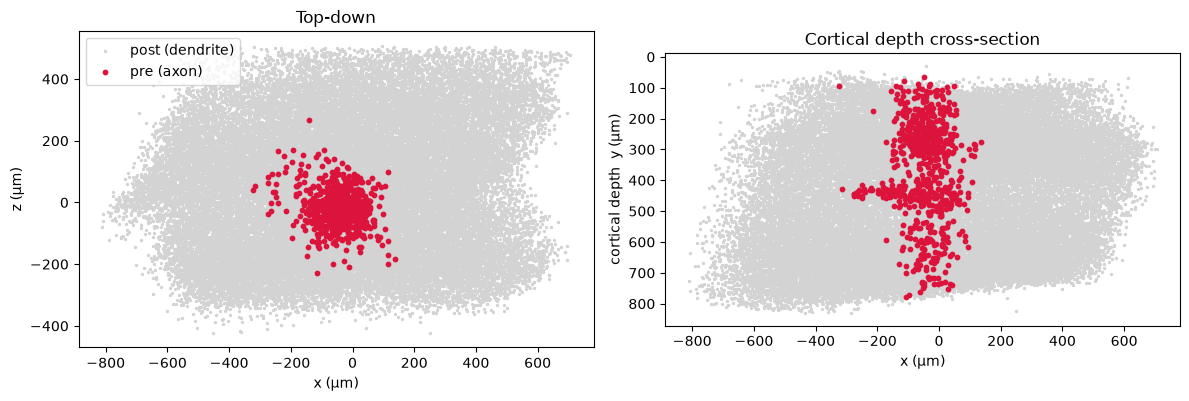

In [7]:
# Presynaptic (proofread axon) vs postsynaptic (proofread dendrite) soma positions.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top-down view: the two lateral axes (x and z)
axes[0].scatter(post_positions[:, 0], post_positions[:, 2], s=2, c="lightgray", label="post (dendrite)")
axes[0].scatter(pre_positions[:, 0], pre_positions[:, 2], s=10, c="crimson", label="pre (axon)")
axes[0].set(xlabel="x (µm)", ylabel="z (µm)", title="Top-down")
axes[0].legend()

# Depth cross-section: lateral x vs cortical depth y
axes[1].scatter(post_positions[:, 0], post_positions[:, 1], s=2, c="lightgray")
axes[1].scatter(pre_positions[:, 0], pre_positions[:, 1], s=10, c="crimson")
axes[1].set(xlabel="x (µm)", ylabel="cortical depth  y (µm)", title="Cortical depth cross-section")
axes[1].invert_yaxis()

for ax in axes:
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

What do you notice about the relative distances between proofread axon and proofread dendrite cells? 
- Do you expect the majority of presynaptic-to-postsynaptic soma distances to be *under or over 100 µm*?
- What *shape* do you expect this distribution to be? 
- What is the *largest distance* you expect to see between a presynaptic and a postsynaptic soma?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 2: **Plot the distribution** of soma–soma distances

Calculate the distance from each presynaptic soma (`pre_positions`) to all postsynaptic somata (`post_positions`). Store these distances in a list for plotting, then plot a histogram of these distances. 


*Hint*: the `distance_from_one_soma` function takes one presynaptic soma coordinate and an array of postsynaptic soma coordinates. 


</div>

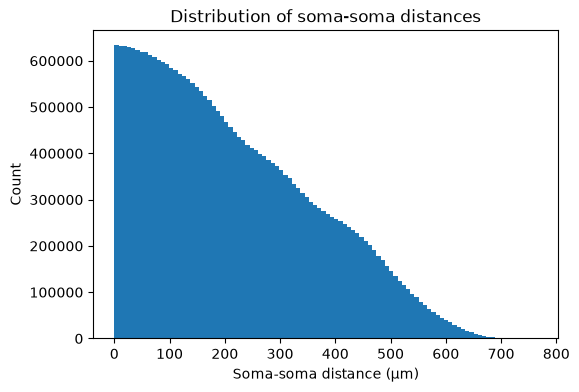

In [8]:
# Distance from every presynaptic soma to every postsynaptic soma.
all_distances = []
for i, pre_id in enumerate(pre_ids):
    all_distances.append(distance_from_one_soma(pre_positions[i], post_positions))
all_distances = np.concatenate(all_distances)

plt.figure(figsize=(6, 4))
plt.hist(all_distances, bins=100)
plt.xlabel("Soma-soma distance (µm)")
plt.ylabel("Count")
plt.title("Distribution of soma-soma distances")
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Two things look off

You just saw that the **postsynaptic** somata spread across the whole volume (well over a millimeter wide), while the **presynaptic** somata sit in a compact sub-region (largely the cortical column). Given that layout:

1. **The range is too short.** The largest computed distance is only ~765 µm, approximately the cortical depth, but given the width of the volume, a superficial presynaptic cell should be much further away from a deep postsynaptic cell near the edge of the volume. 
2. **There is a suspicious pile-up near zero.** Nearly a third of all pairs come out less than 100 µm apart, with the peak of the distribution close to zero. Neuronal somata are ~15–20 µm across and clearly spread through the tissue — they can't overlap that often.

Visualizing raised the alarm, but it doesn't tell us exactly what's wrong. Let's pin it down with a **test case**.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 3: Create a **test case** to assess the soma distance calculation 

The soma distance calculation is in the `distance_from_one_soma` function.

A **test case** is a simple input where you know what the expected output should be.

*Hint*: keep it simple, what is the Euclidean distance between two cells with the same position along two axes but different in the third (e.g., same x and y, different z)?

</div>

In [9]:
# Two somata at different positions but the SAME cortical depth (y).
presynaptic_soma_coord  = np.array([0, 10, 0])
postsynaptic_soma_coord = np.array([[0, 10, 5]])

# What should the distance be?
expected_distance = 5.0

# Run the existing function
calculated_distance = distance_from_one_soma(presynaptic_soma_coord, postsynaptic_soma_coord)[0]

print("Calculated distance:", calculated_distance)
print("Expected distance:  ", expected_distance)

Calculated distance: 0
Expected distance:   5.0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Does the calculated distance match the expected distance?

If so, that tells us something useful! There exists a case where the function returns the expected value. But since we have an intuition that the distance calculation might be wrong, change the soma coordinates to test another case. **Can you identify a scenario where the expected and calculated distances do not match?** *Hint*: see hint above

If not, that also tells us something useful! There must be an error in the distance calculation. Before fixing the code, let's turn this check into a **`unit test`**.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

A **`unit test`** checks whether a specific piece of code, such as a function, behaves as expected for a known input.

In Python, unit tests often use **`assertions`** to compare the actual result with the expected result. An `assertion` checks that a condition is true; if it is not, the test fails.

**`pytest`** is a popular Python package for writing and running unit tests. Test function names must start with `test_` for `pytest` to automatically find and run them. The rest of the name should describe what the test checks, in practice this often includes the name of the function being tested. You can put `test_` functions in a test file (e.g., test_utils.py) and run them with pytest.


We'll first watch the test fail, then inspect the implementation, fix the bug, and rerun the test to confirm the fix.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 4: Turn this check into a **unit test**


*Hint*: how can we deal with floating point differences?

</div>

In [10]:
#write the test function
def test_distance_same_cortical_depth():
    # Two somata at different positions but the same cortical depth (y)
    presynaptic_soma_coord  = np.array([0, 10, 0])
    postsynaptic_soma_coord = np.array([[0, 10, 5]])

    expected_distance = 5.0

    calculated_distance = distance_from_one_soma(presynaptic_soma_coord, postsynaptic_soma_coord)[0]

    assert np.isclose(calculated_distance, expected_distance), (
        f"Expected distance {expected_distance}, "
        f"but got {calculated_distance}"
    )

In [11]:
#run the test function, does it pass?
test_distance_same_cortical_depth()

AssertionError: Expected distance 5.0, but got 0

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 5: **Fix the bug**

Use the failing assertion to guide your debugging of the `distance_from_one_soma` function. Can you identify what is being calculated? Implement the correct Euclidean distance operation. 

- Write more tests to understand what the error in the calculation is. 
- Find and fix the bug in the distance function.
- Rerun the code. Once the unit test passes, continue to the next section.

</div>

In [12]:
# Fix (Check 1): use the full 3-D Euclidean distance, not cortical depth alone.
def distance_from_one_soma(pre_position, post_positions):
    """Euclidean distance from one soma to every candidate postsynaptic soma."""
    return np.linalg.norm(post_positions - pre_position, axis=1)

In [13]:
test_distance_same_cortical_depth()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### **Check 2: Is connection probability calculated correctly?**

Before reading the code, clarify the quantity we want to calculate within each soma-distance bin:

$$
P(\text{connection} \mid \text{distance bin})
=
\frac{???}{???}
$$

* What should be counted in the numerator?
* What should be counted in the denominator?
* Which neuron pairs should be considered eligible?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### **Introducing invariants**

In Check 1 you wrote a **test case**: a specific input whose correct output you worked out by hand. That's powerful, but it only checks the one input you tried.

An **invariant** is different — a property that must hold for **every** valid input. Because it's a property rather than a specific number, you can assert it *without knowing the right answer*. If the code ever violates it, something is wrong.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 6: What should always be true?

Without looking at the implementation, think about properties that must hold if
connection probability is being calculated correctly.

Brainstorm **invariants** of the probability function that would build your confidence in the computation.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 7: Test an invariant of the probability function

Below, we create a random dataset of connected and eligible cell counts.

Choose **one property of the connection probabilities that should always be true**, regardless of the particular values in the dataset. Write an assertion that tests this property.

</div>

In [14]:
def test_connection_probability_property():

    # Seed a random number generator
    rng = np.random.default_rng(0)

    # Create an array of 100 random eligible counts from 1 to 999
    eligible = rng.integers(1, 1000, size=100)

    # Create a random connected count between 0 and the eligible count for each bin
    connected = np.array([rng.integers(0, e + 1) for e in eligible])

    # Compute the connection probabilities for all bins
    p = connection_probability(connected, eligible)

    # Connection probabilities should always be between 0 and 1
    assert np.all((p >= 0) & (p <= 1)), \
        "Connection probabilities must be between 0 and 1"

In [15]:
test_connection_probability_property()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### What did your test tell you?


**If your test passed:** That's useful evidence, the calculation produces a result that always has this property, but it doesn't mean the computation is correct. What other properties could you test?

**If your test failed:** That's also useful, you've found evidence that something is wrong. Can you use a more targeted test to narrow down *what* is going wrong?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 8: Test another invariant of the probability function

Each distance bin's probability should depend **only on that bin's own counts** — not on the other bins in the dataset.

Write an invariant that tests this.

*Hint*: if you append one new distance bin to the dataset, the probabilities of the bins that were already there must not change.

</div>

In [16]:
def test_adding_bin_does_not_change_existing_probabilities():

    # Seed a random number generator
    rng = np.random.default_rng(0)

    # Create an array of 100 random eligible counts from 1 to 999
    eligible = rng.integers(1, 1000, size=100)

    # Create a random connected count between 0 and the eligible count for each bin
    connected = np.array([rng.integers(0, e + 1) for e in eligible])

    # Compute the connection probability
    p_before = connection_probability(connected, eligible)

    # Add a new bin to the dataset
    connected_with_new_bin = np.append(connected, 25)
    eligible_with_new_bin = np.append(eligible, 100)

    # Recompute the connection probability 
    p_after = connection_probability( connected_with_new_bin, eligible_with_new_bin)

    # Adding a new bin should not change the probabilities
    # of the bins that were already in the dataset.
    assert np.allclose(p_before, p_after[:-1]), \
        "Adding a new bin changed existing probabilities."

In [17]:
test_adding_bin_does_not_change_existing_probabilities()

AssertionError: Adding a new bin changed existing probabilities.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### Task 9: **Fix the bug**

Use the failing assertion to guide your debugging.

- Fix the bug in the probability function.
- Rerun the assertion until it passes.
- Once the test passes, continue.

</div>

In [18]:
# Fix (Check 2): each distance bin gets its own denominator.
def connection_probability(connected_counts, total_counts):
    """Connection probability in each distance bin (per-bin denominator)."""
    connected_counts = np.asarray(connected_counts)
    total_counts = np.asarray(total_counts)
    return np.divide(
        connected_counts,
        total_counts,
        out=np.full(connected_counts.shape, np.nan, dtype=float),
        where=total_counts > 0,
    )

In [19]:
test_adding_bin_does_not_change_existing_probabilities()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Assess the updated figure

Re-run the analysis with the corrected functions and compare this figure to the one we started with. Do you trust the result? What other evidence would you want to gather?

</div>

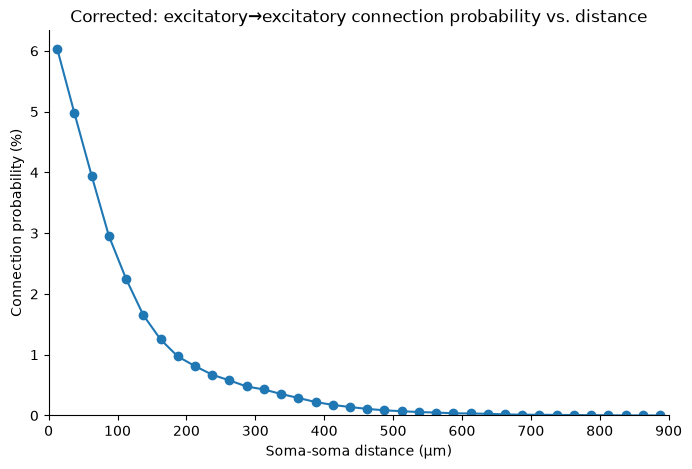

In [20]:
edges, total_counts, connected_counts = count_pairs_by_distance(
    pre_ids, post_ids, pre_positions, post_positions, connected_pairs,
    bin_width_um=BIN_WIDTH_UM, max_distance_um=MAX_DISTANCE_UM,
)
probability = connection_probability(connected_counts, total_counts)

centers = (edges[:-1] + edges[1:]) / 2

reliable = total_counts >= MIN_PAIRS_PER_BIN
show = reliable & np.isfinite(probability)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers[show], probability[show] * 100, marker="o")
ax.set(
    xlabel="Soma-soma distance (µm)",
    ylabel="Connection probability (%)",
    title="Corrected: excitatory→excitatory connection probability vs. distance",
    xlim=(0, MAX_DISTANCE_UM),
    ylim=(0, None),
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Another way to build confidence: compare to peer-reviewed studies

Another way to evaluate an analysis is to compare your results to independent findings from the scientific literature.

If previous studies using the same or similar datasets report comparable trends, that increases confidence that your implementation is reasonable. If your results differ substantially, that's a signal to investigate further—it may reveal a bug, a difference in methodology, or a genuinely new finding.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### **Extension: compare to the literature**

* **Find one or more published studies** related to excitatory-to-excitatory connection probability as a function of soma distance.
* Compare their findings to your result.
* **Does the comparison increase or decrease your confidence** in the analysis? Why?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Discussion

### What other assumptions would you want to test, and how could you test them?

Think beyond the bugs we found today. What assumptions does this analysis make about the data, filtering, units, neuron identities, eligible pairs, binning, or interpretation of the result?

For each assumption, identify a piece of evidence that would increase—or decrease—your confidence in the analysis.

</div>